# 🛍️ Customer Segmentation using K-Means Clustering

**Author:** Yuval Varke

## 📌 Description
This project applies **K-Means Clustering** to segment customers of a retail store based on:
- **Annual Income (k$)**
- **Spending Score (1-100)**

By grouping customers into clusters, businesses can better understand customer behavior and design targeted marketing strategies.

## 📂 Dataset
**Name:** Customer Segmentation
**Source:** [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import os, warnings

In [5]:
sns.set(style="whitegrid")
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
data = pd.read_csv("Mall_Customers.csv")
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Elbow Method - Find Optimal K

In [8]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

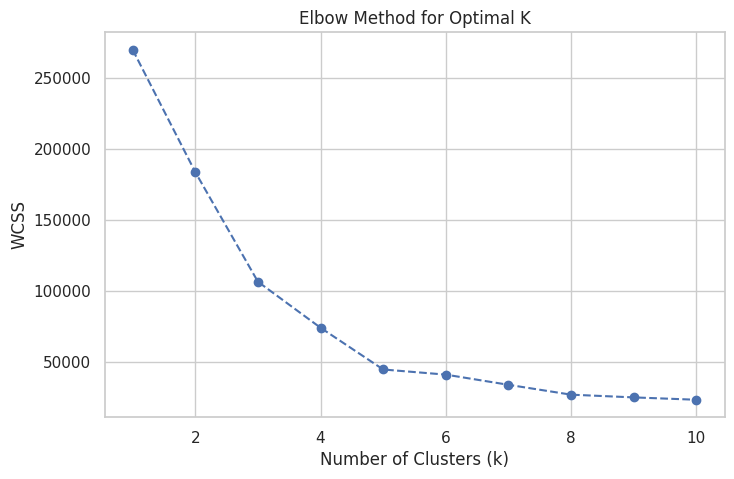

In [9]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

### Train KMeans with Optimal K

In [10]:
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)

data['Cluster'] = y_kmeans
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Visualize Clusters

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

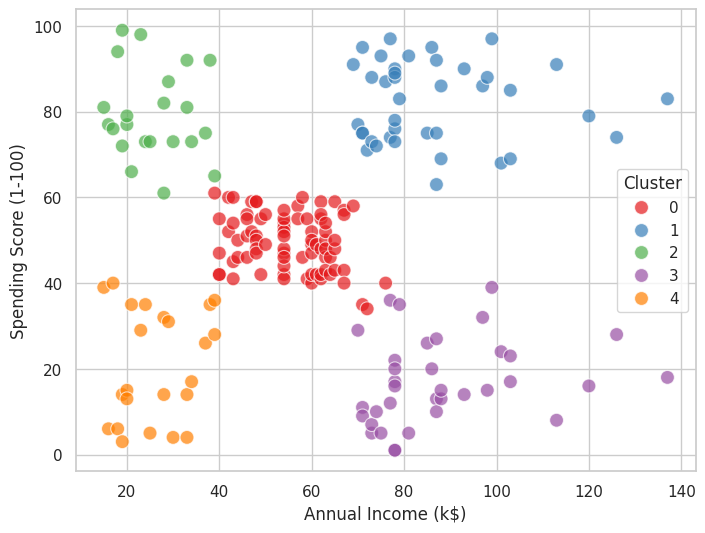

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=data,
    s=100,
    alpha=0.7
)

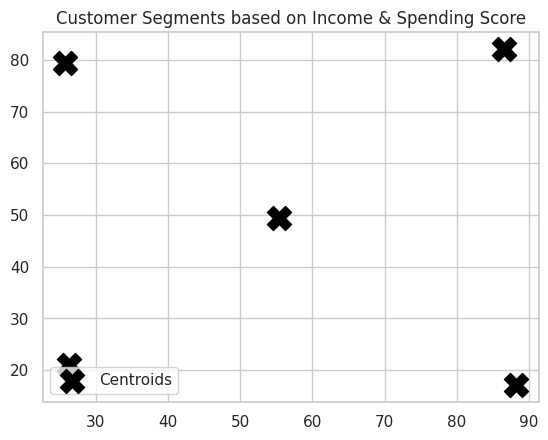

In [12]:
# Plot cluster centroids
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1],
    s=300, c='black', marker='X', label='Centroids'
)

plt.title("Customer Segments based on Income & Spending Score")
plt.legend()
plt.show()